In [ ]:
!pip install pyinaturalist requests Pillow

import requests
import os
from PIL import Image
from io import BytesIO
import pyinaturalist as pyinat

# Plantae taxon ID on iNaturalist = 47126
# This streams observations one page at a time — never loads everything at once

DATA_DIR = './data/plants_class'
PER_PAGE = 100
MAX_PAGES = 50  # adjust this — 50 pages = ~5000 images, manageable size

for page in range(1, MAX_PAGES + 1):
    print(f'Fetching page {page}/{MAX_PAGES}...')
    response = requests.get('https://api.inaturalist.org/v1/observations', params={
        'taxon_id': 47126,        # Plantae
        'quality_grade': 'research',  # only verified observations
        'photos': True,
        'per_page': PER_PAGE,
        'page': page,
        'order_by': 'id',
    }).json()

    for obs in response.get('results', []):
        try:
            taxon = obs.get('taxon', {})
            if not taxon:
                continue

            plant_class = taxon.get('iconic_taxon_name') or taxon.get('rank_level')
            # Get the actual class from ancestry
            ancestors = taxon.get('ancestors', [])
            class_name = next(
                (a['name'] for a in ancestors if a.get('rank') == 'class'),
                None
            )
            if not class_name:
                continue

            # Download the photo
            photo_url = obs['photos'][0]['url'].replace('square', 'medium')
            img_data = requests.get(photo_url, timeout=5).content
            img = Image.open(BytesIO(img_data)).convert('RGB')

            # Save to folder
            folder = os.path.join(DATA_DIR, class_name.replace(' ', '_'))
            os.makedirs(folder, exist_ok=True)
            count = len(os.listdir(folder))
            img.save(os.path.join(folder, f'{count:05d}.jpg'))

        except Exception as e:
            continue  # skip any bad observations silently

print('Done!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.1/141.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.3 MB/s eta 0:00:00
Fetching page 1/50...
Fetching page 2/50...
Fetching page 3/50...
Fetching page 4/50...
Fetching page 5/50...
Fetching page 6/50...
Fetching page 7/50...
Fetching page 8/50...
Fetching page 9/50...
Fetching page 10/50...
Fetching page 11/50...
Fetching page 12/50...
Fetching page 13/50...
Fetching page 14/50...
Fetching page 15/50...
Fetching page 16/50...
Fetching page 17/50...
Fetching page 18/50...
Fetching page 19/50...
Fetching page 20/50...
Fetching page 21/50...
Fetching page 22/50...
Fetching page 23/50...
Fetching page 24/50...
Fetching page 25/50...
Fetching page 26/50...
Fetching page 27/50...
Fetching page 28/50...
Fetching page 29/50...
Fetching page 30/50...
Fetching page 31/50...
Fetching page 32/50...
Fetching page 33/50...
Fetching page 

In [ ]:
import requests

# Fetch one page and inspect what we're actually getting
response = requests.get('https://api.inaturalist.org/v1/observations', params={
    'taxon_id': 47126,
    'quality_grade': 'research',
    'photos': True,
    'per_page': 3,
    'page': 1,
    'order_by': 'id',
}).json()

for obs in response['results']:
    taxon = obs.get('taxon', {})
    print('--- Observation ---')
    print('Taxon name:', taxon.get('name'))
    print('Rank:', taxon.get('rank'))
    print('Ancestors:', taxon.get('ancestors'))  # this is probably None or []
    print('Photos:', obs['photos'][0]['url'] if obs.get('photos') else 'none')
    print()

--- Observation ---
Taxon name: Passiflora lutea
Rank: species
Ancestors: None
Photos: https://inaturalist-open-data.s3.amazonaws.com/photos/649036326/square.jpg

--- Observation ---
Taxon name: Camassia leichtlinii
Rank: species
Ancestors: None
Photos: https://inaturalist-open-data.s3.amazonaws.com/photos/649023815/square.jpg

--- Observation ---
Taxon name: Corallorhiza maculata
Rank: species
Ancestors: None
Photos: https://inaturalist-open-data.s3.amazonaws.com/photos/649034915/square.jpg



In [ ]:
import requests
import os
import time
from PIL import Image
from io import BytesIO

DATA_DIR = './data/plants_class'
PER_PAGE = 100
MAX_PAGES = 50

taxon_class_cache = {}

def get_plant_class(taxon_id):
    if taxon_id in taxon_class_cache:
        return taxon_class_cache[taxon_id]

    for attempt in range(3):  # retry up to 3 times
        try:
            r = requests.get(
                f'https://api.inaturalist.org/v1/taxa/{taxon_id}',
                timeout=10
            )
            if r.status_code == 429:  # rate limited
                print('Rate limited, waiting 60s...')
                time.sleep(60)
                continue
            if r.status_code != 200:
                return None
            data = r.json()
            ancestors = data['results'][0].get('ancestors', [])
            class_name = next(
                (a['name'] for a in ancestors if a.get('rank') == 'class'),
                None
            )
            taxon_class_cache[taxon_id] = class_name
            time.sleep(0.5)  # be polite to the API
            return class_name
        except Exception:
            time.sleep(2)
    return None

for page in range(1, MAX_PAGES + 1):
    print(f'Fetching page {page}/{MAX_PAGES}...')

    for attempt in range(3):
        try:
            response = requests.get(
                'https://api.inaturalist.org/v1/observations',
                params={
                    'taxon_id': 47126,
                    'quality_grade': 'research',
                    'photos': True,
                    'per_page': PER_PAGE,
                    'page': page,
                    'order_by': 'id',
                },
                timeout=10
            )
            if response.status_code == 429:
                print('Rate limited, waiting 60s...')
                time.sleep(60)
                continue
            results = response.json().get('results', [])
            break
        except Exception:
            time.sleep(5)
            results = []

    for obs in results:
        try:
            taxon = obs.get('taxon', {})
            if not taxon:
                continue

            class_name = get_plant_class(taxon['id'])
            if not class_name:
                continue

            photo_url = obs['photos'][0]['url'].replace('square', 'medium')
            img_data = requests.get(photo_url, timeout=10).content
            img = Image.open(BytesIO(img_data)).convert('RGB')

            folder = os.path.join(DATA_DIR, class_name.replace(' ', '_'))
            os.makedirs(folder, exist_ok=True)
            count = len(os.listdir(folder))
            img.save(os.path.join(folder, f'{count:05d}.jpg'))

        except Exception:
            continue

    time.sleep(1)  # pause between pages

print('Done!')

Fetching page 1/50...
Fetching page 2/50...
Fetching page 3/50...
Fetching page 4/50...
Fetching page 5/50...
Fetching page 6/50...
Fetching page 7/50...
Fetching page 8/50...
Fetching page 9/50...
Fetching page 10/50...
Fetching page 11/50...
Fetching page 12/50...
Fetching page 13/50...
Fetching page 14/50...
Fetching page 15/50...
Fetching page 16/50...
Fetching page 17/50...
Fetching page 18/50...
Fetching page 19/50...
Fetching page 20/50...
Fetching page 21/50...
Fetching page 22/50...
Fetching page 23/50...
Fetching page 24/50...
Fetching page 25/50...
Fetching page 26/50...
Fetching page 27/50...
Fetching page 28/50...
Fetching page 29/50...
Fetching page 30/50...
Fetching page 31/50...
Fetching page 32/50...
Fetching page 33/50...
Fetching page 34/50...
Fetching page 35/50...
Fetching page 36/50...
Fetching page 37/50...
Fetching page 38/50...
Fetching page 39/50...
Fetching page 40/50...
Fetching page 41/50...
Fetching page 42/50...
Fetching page 43/50...
Fetching page 44/50.

In [ ]:
import os

DATA_DIR = './data/plants_class'

classes = sorted(os.listdir(DATA_DIR))
print(f'Number of plant classes: {len(classes)}')
print()

total = 0
for cls in classes:
    count = len(os.listdir(os.path.join(DATA_DIR, cls)))
    total += count
    print(f'  {cls}: {count} images')

print(f'\nTotal images: {total}')

Number of plant classes: 8

  Bryopsida: 8 images
  Liliopsida: 987 images
  Lycopodiopsida: 5 images
  Magnoliopsida: 3896 images
  Pinopsida: 68 images
  Polypodiopsida: 191 images
  Polytrichopsida: 1 images
  Ulvophyceae: 3 images

Total images: 5159


In [ ]:
import shutil

# Classes with too few images to train on
DROP_CLASSES = ['Bryopsida', 'Lycopodiopsida', 'Polytrichopsida', 'Ulvophyceae']

for cls in DROP_CLASSES:
    path = os.path.join(DATA_DIR, cls)
    if os.path.exists(path):
        shutil.rmtree(path)
        print(f'Removed {cls}')

# Cap Magnoliopsida to 1000 so it doesn't dominate
import random
mag_path = os.path.join(DATA_DIR, 'Magnoliopsida')
imgs = os.listdir(mag_path)
random.shuffle(imgs)
for img in imgs[1000:]:  # keep first 1000, delete the rest
    os.remove(os.path.join(mag_path, img))

print('\nAfter cleanup:')
for cls in sorted(os.listdir(DATA_DIR)):
    count = len(os.listdir(os.path.join(DATA_DIR, cls)))
    print(f'  {cls}: {count} images')

Removed Bryopsida
Removed Lycopodiopsida
Removed Polytrichopsida
Removed Ulvophyceae

After cleanup:
  Liliopsida: 987 images
  Magnoliopsida: 1000 images
  Pinopsida: 68 images
  Polypodiopsida: 191 images


In [ ]:
# Taxon IDs for the underrepresented classes
TAXON_IDS = {
    'Pinopsida': 136329,
    'Polypodiopsida': 121943,
}
TARGET = 500  # how many images we want per class

for class_name, taxon_id in TAXON_IDS.items():
    folder = os.path.join(DATA_DIR, class_name)
    current = len(os.listdir(folder))
    needed = TARGET - current
    print(f'{class_name}: has {current}, fetching {needed} more...')

    fetched = 0
    page = 1
    while fetched < needed and page <= 100:
        try:
            response = requests.get(
                'https://api.inaturalist.org/v1/observations',
                params={
                    'taxon_id': taxon_id,
                    'quality_grade': 'research',
                    'photos': True,
                    'per_page': 100,
                    'page': page,
                    'order_by': 'id',
                },
                timeout=10
            ).json()

            results = response.get('results', [])
            if not results:
                break

            for obs in results:
                if fetched >= needed:
                    break
                try:
                    photo_url = obs['photos'][0]['url'].replace('square', 'medium')
                    img_data = requests.get(photo_url, timeout=10).content
                    img = Image.open(BytesIO(img_data)).convert('RGB')
                    count = len(os.listdir(folder))
                    img.save(os.path.join(folder, f'{count:05d}.jpg'))
                    fetched += 1
                except Exception:
                    continue

            page += 1
            time.sleep(1)

        except Exception as e:
            print(f'Error on page {page}: {e}')
            time.sleep(5)
            page += 1

    print(f'  Done! {class_name} now has {len(os.listdir(folder))} images')

Pinopsida: has 68, fetching 432 more...
  Done! Pinopsida now has 500 images
Polypodiopsida: has 191, fetching 309 more...
  Done! Polypodiopsida now has 500 images


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [ ]:
DATA_DIR = './data/plants_class'

classes = sorted(os.listdir(DATA_DIR))
print(f'Number of plant classes: {len(classes)}')
print()

total = 0
for cls in classes:
    count = len(os.listdir(os.path.join(DATA_DIR, cls)))
    total += count
    print(f'  {cls}: {count} images')
print(f'\nTotal images: {total}')

Number of plant classes: 4

  Liliopsida: 987 images
  Magnoliopsida: 1000 images
  Pinopsida: 500 images
  Polypodiopsida: 500 images

Total images: 2987


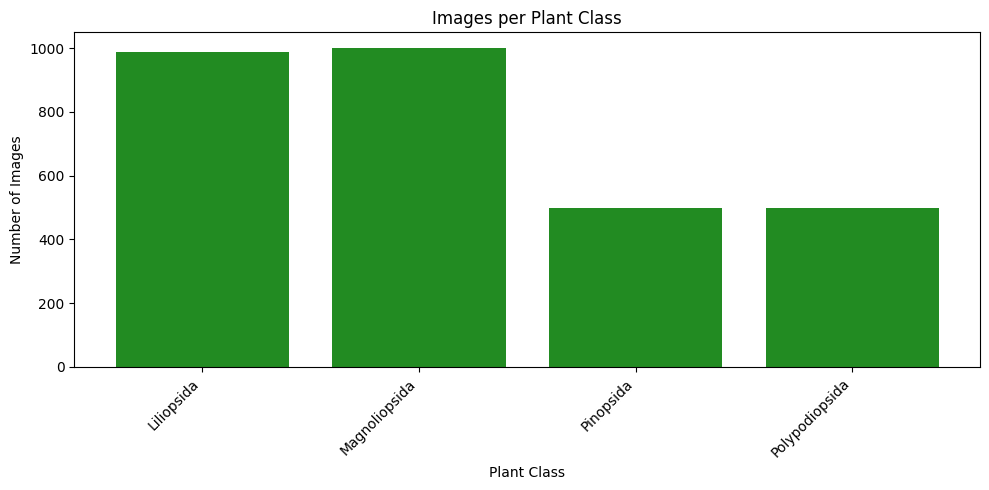

In [ ]:
class_counts = {cls: len(os.listdir(os.path.join(DATA_DIR, cls))) for cls in classes}

plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='forestgreen')
plt.title('Images per Plant Class')
plt.xlabel('Plant Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

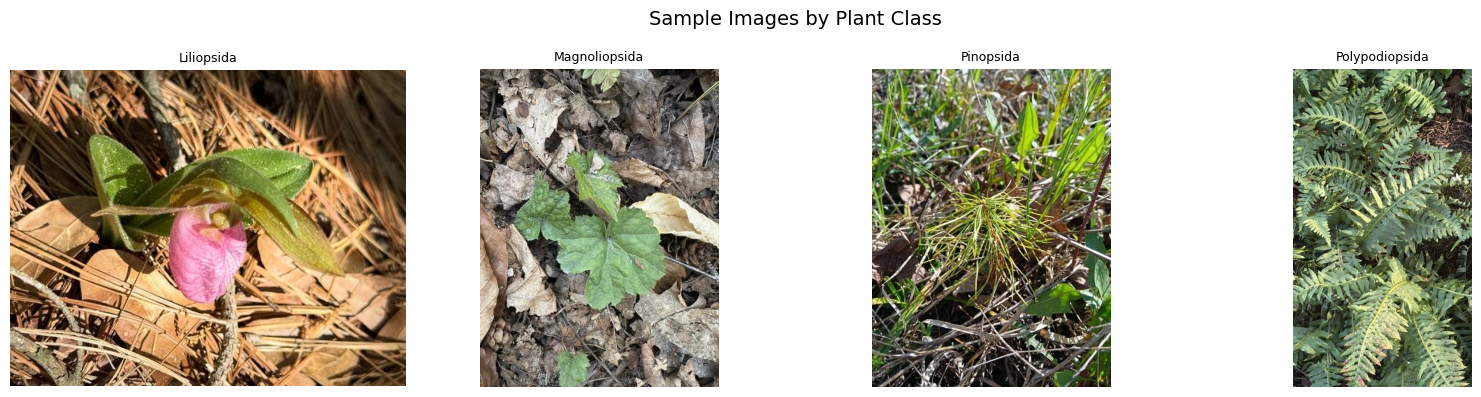

In [ ]:
fig, axes = plt.subplots(1, len(classes), figsize=(4 * len(classes), 4))

for ax, cls in zip(axes, classes):
    cls_path = os.path.join(DATA_DIR, cls)
    img_file = os.listdir(cls_path)[0]
    img = Image.open(os.path.join(cls_path, img_file)).convert('RGB')
    ax.imshow(img)
    ax.set_title(cls, fontsize=9)
    ax.axis('off')

plt.suptitle('Sample Images by Plant Class', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print('Transforms defined!')

Transforms defined!


In [ ]:
full_dataset = ImageFolder(root=DATA_DIR, transform=None)

class_to_idx = full_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}
NUM_CLASSES = len(class_to_idx)
print('Class to index mapping:', class_to_idx)
print(f'Total samples: {len(full_dataset)}')

total = len(full_dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

train_data, val_data, test_data = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)
print(f'Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')

Class to index mapping: {'Liliopsida': 0, 'Magnoliopsida': 1, 'Pinopsida': 2, 'Polypodiopsida': 3}
Total samples: 2987
Train: 2090 | Val: 448 | Test: 449


In [ ]:
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset = TransformSubset(train_data, train_transforms)
val_dataset   = TransformSubset(val_data,   val_test_transforms)
test_dataset  = TransformSubset(test_data,  val_test_transforms)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print('DataLoaders ready!')

DataLoaders ready!


In [ ]:
model = models.resnet18(weights='IMAGENET1K_V1')

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

print(f'Model ready! Output classes: {NUM_CLASSES}')
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 43.8MB/s]


Model ready! Output classes: 4
Trainable params: 2,052


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)
print('Optimizer and scheduler ready!')

Optimizer and scheduler ready!


In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

print('Training functions defined!')

Training functions defined!


In [ ]:
NUM_EPOCHS = 10

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

best_val_acc = 0
best_model_path = 'best_plants_class_model.pth'

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_acc   = eval_epoch(model,  val_loader,   criterion)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(f'Epoch {epoch+1:02d}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')

Epoch 01/10 | Train Loss: 1.1598 Acc: 0.4828 | Val Loss: 0.9935 Acc: 0.5804
Epoch 02/10 | Train Loss: 0.9457 Acc: 0.6100 | Val Loss: 0.9099 Acc: 0.6250
Epoch 03/10 | Train Loss: 0.8907 Acc: 0.6301 | Val Loss: 0.8433 Acc: 0.6562
Epoch 04/10 | Train Loss: 0.8463 Acc: 0.6627 | Val Loss: 0.8213 Acc: 0.6719
Epoch 05/10 | Train Loss: 0.8194 Acc: 0.6670 | Val Loss: 0.8264 Acc: 0.6853
Epoch 06/10 | Train Loss: 0.8238 Acc: 0.6622 | Val Loss: 0.8458 Acc: 0.6562
Epoch 07/10 | Train Loss: 0.8142 Acc: 0.6584 | Val Loss: 0.8076 Acc: 0.7031
Epoch 08/10 | Train Loss: 0.7849 Acc: 0.6737 | Val Loss: 0.7854 Acc: 0.6987
Epoch 09/10 | Train Loss: 0.7765 Acc: 0.6756 | Val Loss: 0.8052 Acc: 0.6585
Epoch 10/10 | Train Loss: 0.7662 Acc: 0.6866 | Val Loss: 0.7816 Acc: 0.6964

Best Val Accuracy: 0.7031


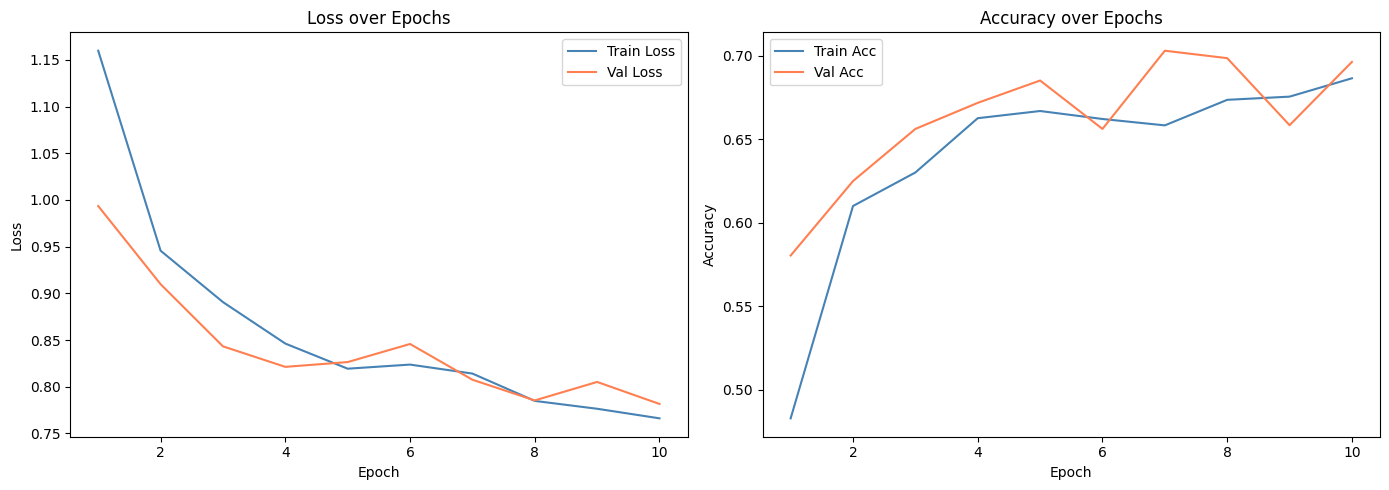

In [ ]:
epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_losses, label='Train Loss', color='steelblue')
ax1.plot(epochs, val_losses,   label='Val Loss',   color='coral')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, train_accs, label='Train Acc', color='steelblue')
ax2.plot(epochs, val_accs,   label='Val Acc',   color='coral')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
class_names = [idx_to_class[i] for i in range(NUM_CLASSES)]

general_accuracy = (all_preds == all_labels).mean()
print(f'General Accuracy: {general_accuracy:.4f} ({general_accuracy*100:.2f}%)')
print()

cm = confusion_matrix(all_labels, all_preds)
true_positives  = np.diag(cm)
false_positives = cm.sum(axis=0) - true_positives
actual_totals   = cm.sum(axis=1)

print(f'{"Class":<20} {"TP":>6} {"FP":>6} {"Actual":>8} {"Precision":>10}')
print('-' * 55)
for i, cls in enumerate(class_names):
    tp = true_positives[i]
    fp = false_positives[i]
    actual = actual_totals[i]
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f'{cls:<20} {tp:>6} {fp:>6} {actual:>8} {precision:>10.4f}')

General Accuracy: 0.6437 (64.37%)

Class                    TP     FP   Actual  Precision
-------------------------------------------------------
Liliopsida              106     91      127     0.5381
Magnoliopsida            76     35      154     0.6847
Pinopsida                53     17       86     0.7571
Polypodiopsida           54     17       82     0.7606


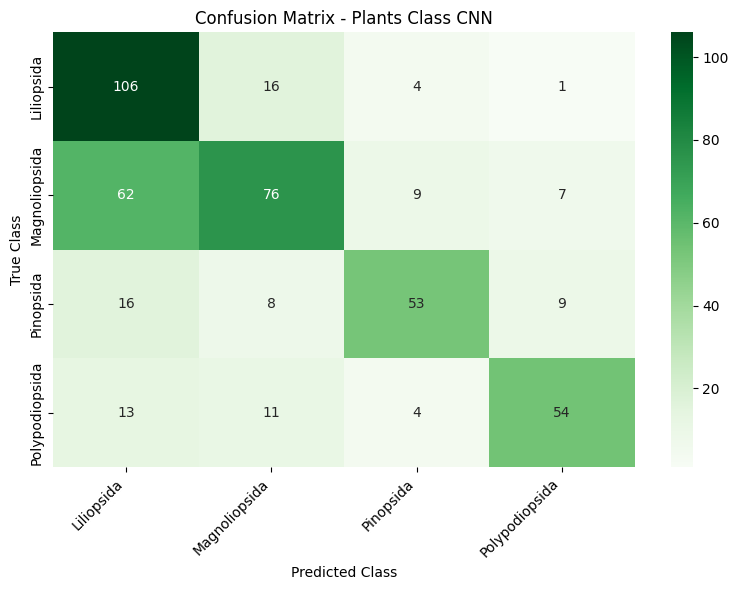

                precision    recall  f1-score   support

    Liliopsida       0.54      0.83      0.65       127
 Magnoliopsida       0.68      0.49      0.57       154
     Pinopsida       0.76      0.62      0.68        86
Polypodiopsida       0.76      0.66      0.71        82

      accuracy                           0.64       449
     macro avg       0.69      0.65      0.65       449
  weighted avg       0.67      0.64      0.64       449



In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Greens'
)
plt.title('Confusion Matrix - Plants Class CNN')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy(best_model_path, '/content/drive/MyDrive/best_plants_class_model.pth')
print('Model saved to Google Drive!')

Mounted at /content/drive
Model saved to Google Drive!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('/content/drive/MyDrive/best_plants_class_model.pth', './best_plants_class_model.pth')

import os
size = os.path.getsize('best_plants_class_model.pth') / (1024 * 1024)
print(f'Model size: {size:.1f} MB')

Mounted at /content/drive
Model size: 42.7 MB


In [3]:
import os
DATA_DIR = './data/plants_class'
if os.path.exists(DATA_DIR):
    classes = os.listdir(DATA_DIR)
    print('Data found! Classes:', classes)
else:
    print('Data not found, need to reload')

Data not found, need to reload


In [4]:
import shutil
shutil.copytree('/content/drive/MyDrive/plants_class', './data/plants_class')
print('Done!')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/plants_class'